# Reproduce the seven PixelCNN experiments

This notebook uses the repository CLI. It separates reading the released reference results, checking synthetic CPU examples, evaluating pretrained weights, and running a fresh training experiment.

The reference files describe one historical training seed. The full training cells are explicitly disabled by default because they traverse the training set 442 times. Enable the corresponding flags when you want to run those commands. Install the project with `python -m pip install -e .` before opening the notebook.

In [1]:
import json
import subprocess
import sys
from pathlib import Path
from IPython.display import Markdown, Image, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / "pyproject.toml").is_file(), "Open this notebook from the repository root or notebooks directory."
DEVICE = "auto"  # Use "cpu" for CPU execution, or "cuda" for a CUDA GPU.

# Keep subprocess output readable without printing local executable paths.
def run_command(arguments):
    result = subprocess.run([sys.executable, *arguments], cwd=PROJECT_ROOT,
                            capture_output=True, text=True)
    print(result.stdout.rstrip())
    if result.returncode:
        print(result.stderr.rstrip())
        raise RuntimeError("Command failed; inspect the error output above.")

def cli(*arguments):
    run_command(["-m", "ucas_generative_ai", *arguments])

print("Project:", PROJECT_ROOT.name)
print("Python:", sys.version.split()[0])

Project: Generative-AI-UCAS-Homework
Python: 3.9.23


## 1. Verify the released files and implementation

The first command checks the SHA256 manifest for the recorded result files and seven checkpoints. The smoke command uses small synthetic examples on CPU; it does not download MNIST or reproduce a full training run.

In [2]:
run_command(["scripts/verify_reference.py"])
cli("smoke")

Reference files and seven checkpoints verified: 73


{
  "mask_forward_and_zero_excluded_gradient": "PASS",
  "normalization_channels_only": "PASS",
  "standard_gated_dropout_causality_and_joint_normalization": "PASS",
  "sampler_first_row_column_and_all_784_positions": "PASS",
  "ema_parameter_formula_and_buffer_copy": "PASS",
  "standard_complete_epoch_resume_all_states_exact": "PASS",
  "evaluation_image_pixel_units": "PASS",
  "dropout_ema_complete_epoch_resume_all_states_exact": "PASS",
  "finished_fine_run_restores_without_extra_updates": "PASS",
  "recorded_protocols": "PASS",
  "overall": "PASS"
}


## 2. Read the recorded experiments

The split is 55,000 training, 5,000 validation, and 10,000 official test images. Every pixel is statically binarized using `uint8 >= 128`. The published values are NLL in nats per image. Historical S1 and S3 test values are absent because those candidates were compared using validation scores.

| Experiment | Actual epochs | Best epoch | Weights | Validation NLL | Test NLL |
|---|---:|---:|---|---:|---:|
| S0 | 25 | 25 | raw | 62.1652 | 62.1889 |
| S1 | 100 | 68 | raw | 60.5759 | — |
| S2 | 100 | 47 | raw | 60.4642 | 60.4827 |
| S3 | 100 | 45 | raw | 60.5535 | — |
| G | 100 | 9 | raw | 55.1815 | 55.3111 |
| F0 | 8 | 3 | ema | 54.5623 | 54.6944 |
| F0.2 | 9 | 4 | ema | 54.4841 | 54.6024 |

Total recorded training-data traversals: 442


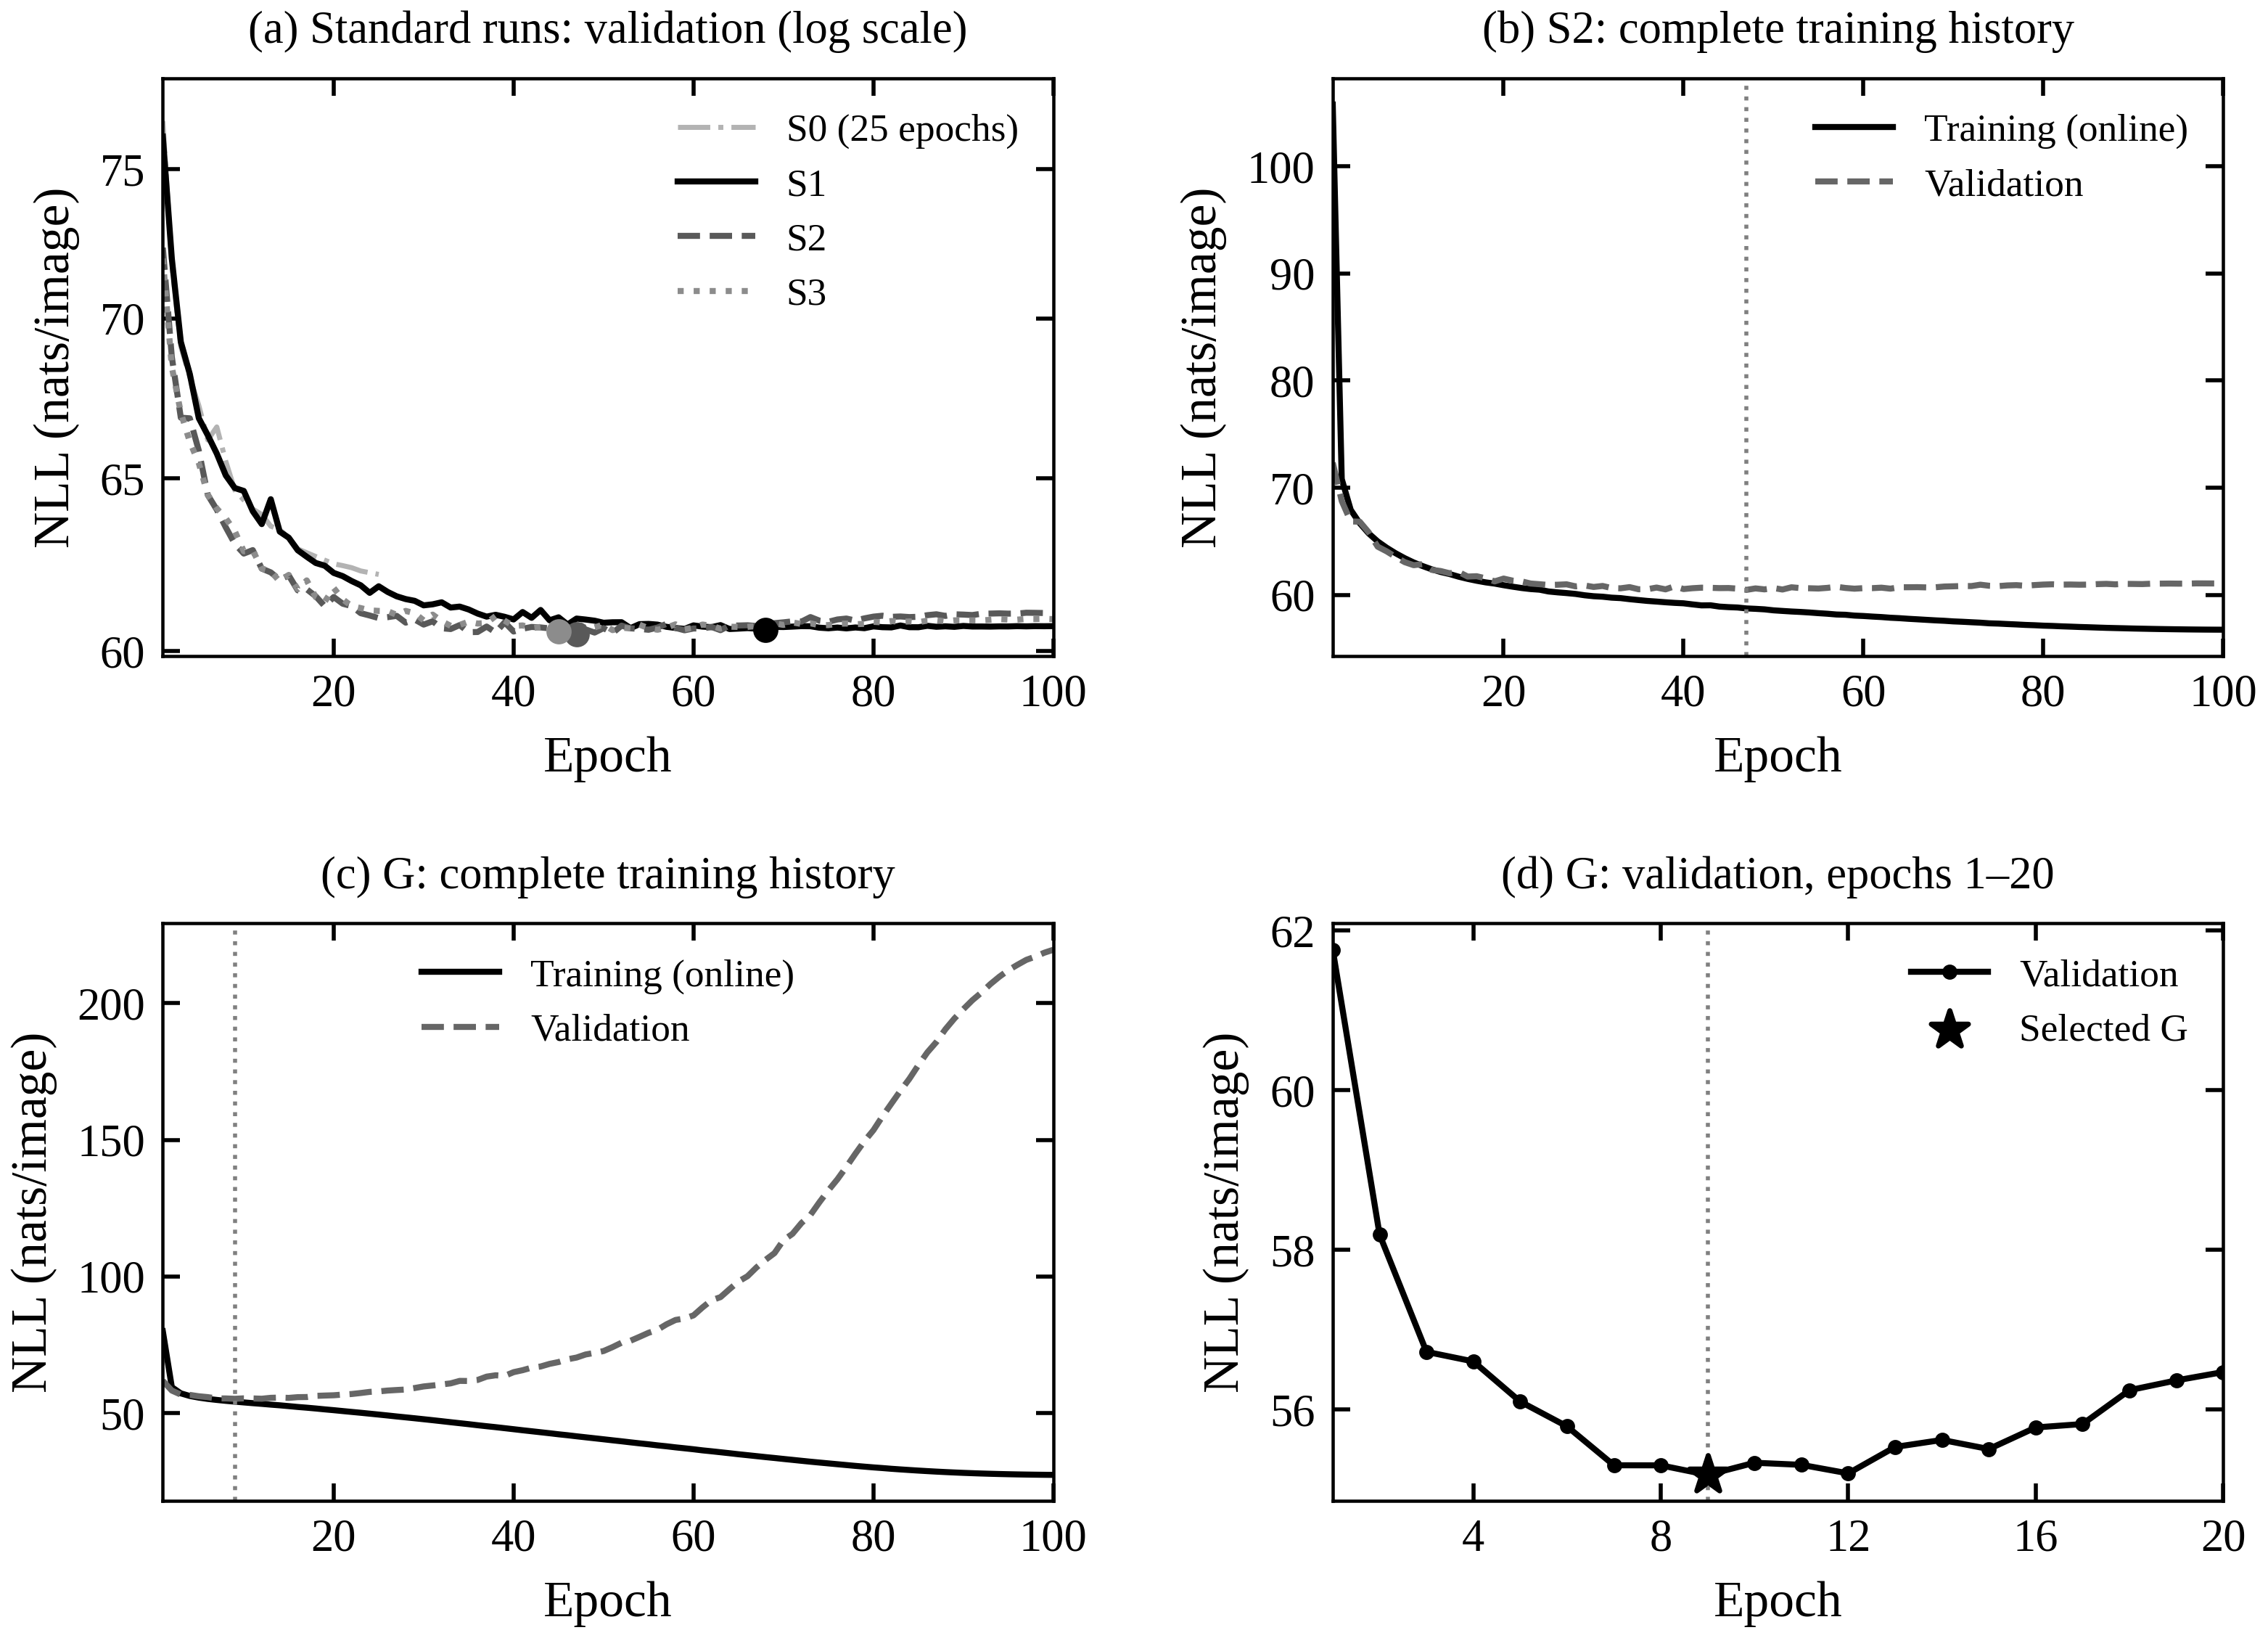

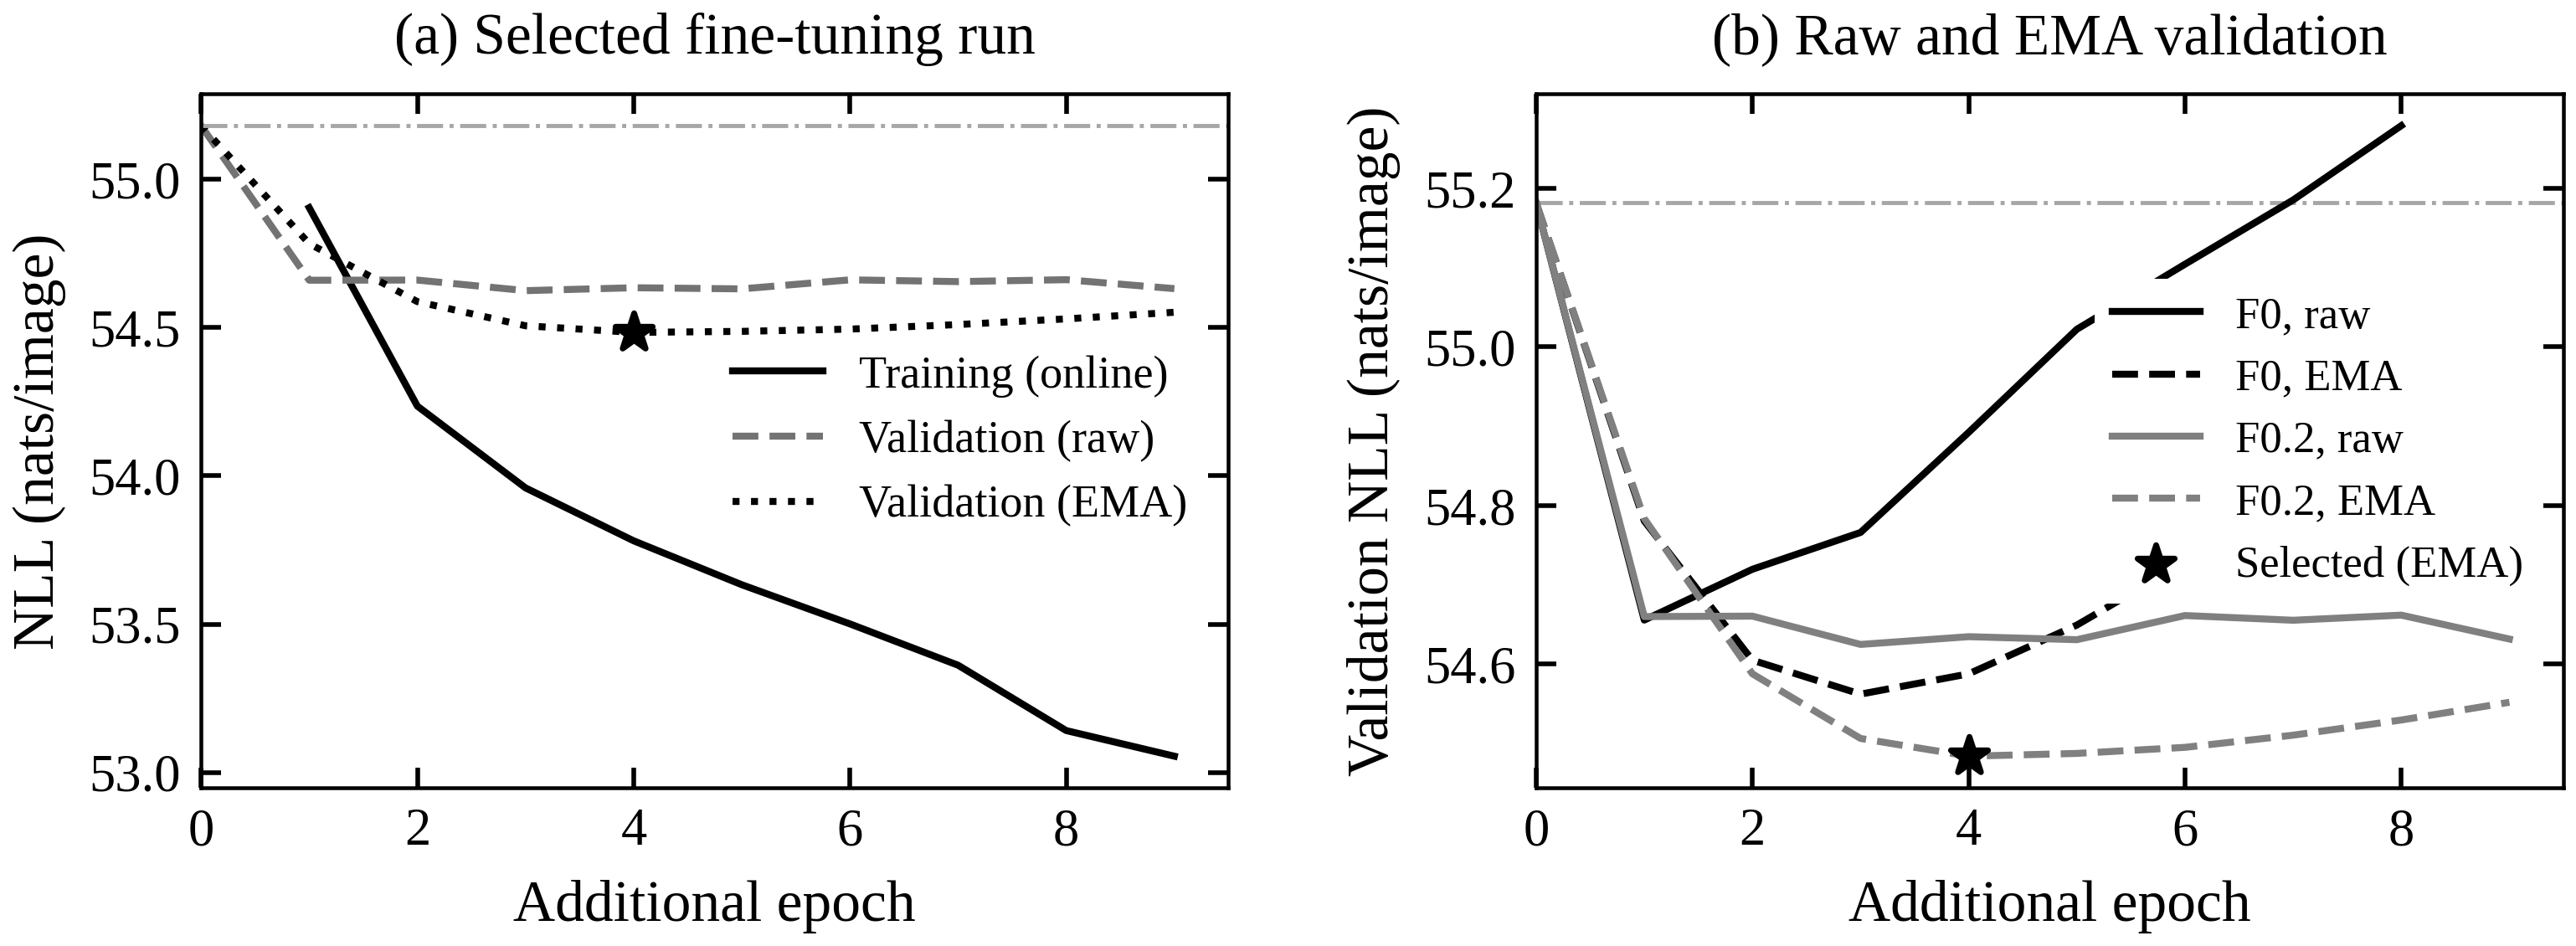

In [3]:
reference = json.loads((PROJECT_ROOT / "results" / "summary.json").read_text())
rows = ["| Experiment | Actual epochs | Best epoch | Weights | Validation NLL | Test NLL |",
        "|---|---:|---:|---|---:|---:|"]
for entry in reference["experiments"]:
    label = "F0.2" if entry["experiment"] == "f02" else entry["experiment"].upper()
    test = "—" if entry["test_nll"] is None else f'{entry["test_nll"]:.4f}'
    rows.append(f'| {label} | {entry["completed_epochs"]} | {entry["best_epoch"]} | '
                f'{entry["weight_source"]} | {entry["validation_nll"]:.4f} | {test} |')
display(Markdown("\n".join(rows)))
print("Total recorded training-data traversals:", reference["total_distinct_training_epochs"])
display(Image(filename=str(PROJECT_ROOT / "docs" / "figures" / "stage-learning-curves.png")))
display(Image(filename=str(PROJECT_ROOT / "docs" / "figures" / "finetuning-curves.png")))

S0 changes both the cosine schedule and training duration relative to S1. S1/S2 change the batch size and therefore the number of update attempts per epoch. G changes gating, context paths, and parameter count together.

F0 and F0.2 use the same G epoch-9 starting weights and fresh Adam. Their additional epochs start at zero; they are not appended to G's epoch-100 parameters. The best raw/EMA validation score selects saved weights, while the 0.02 threshold controls the plateau scheduler and early stopping.

## 3. Evaluate a released checkpoint

Enable this cell to download MNIST and evaluate the entire official test split with the published F0.2 weights. This is pretrained evaluation, not training. Evaluation is FP32. Different hardware or library versions can introduce numerical differences.

In [4]:
RUN_EVALUATION = False
if RUN_EVALUATION:
    cli("evaluate", "--checkpoint", "checkpoints/f02.pt", "--experiment", "f02",
        "--split", "test", "--data-root", "data", "--device", DEVICE,
        "--baselines", "--output", "reproduced/f02-test.json")
else:
    print("Pretrained evaluation is disabled. Set RUN_EVALUATION=True to run it.")

Pretrained evaluation is disabled. Set RUN_EVALUATION=True to run it.


## 4. Generate a complete batch

Autoregressive sampling starts from zeros and visits all 784 positions, including the first row and first column. It uses no labels or true image prefixes. CPU sampling can be slow because each pixel requires a model forward. The fixed integer seed controls sampling randomness, but CPU and CUDA need not produce identical images.

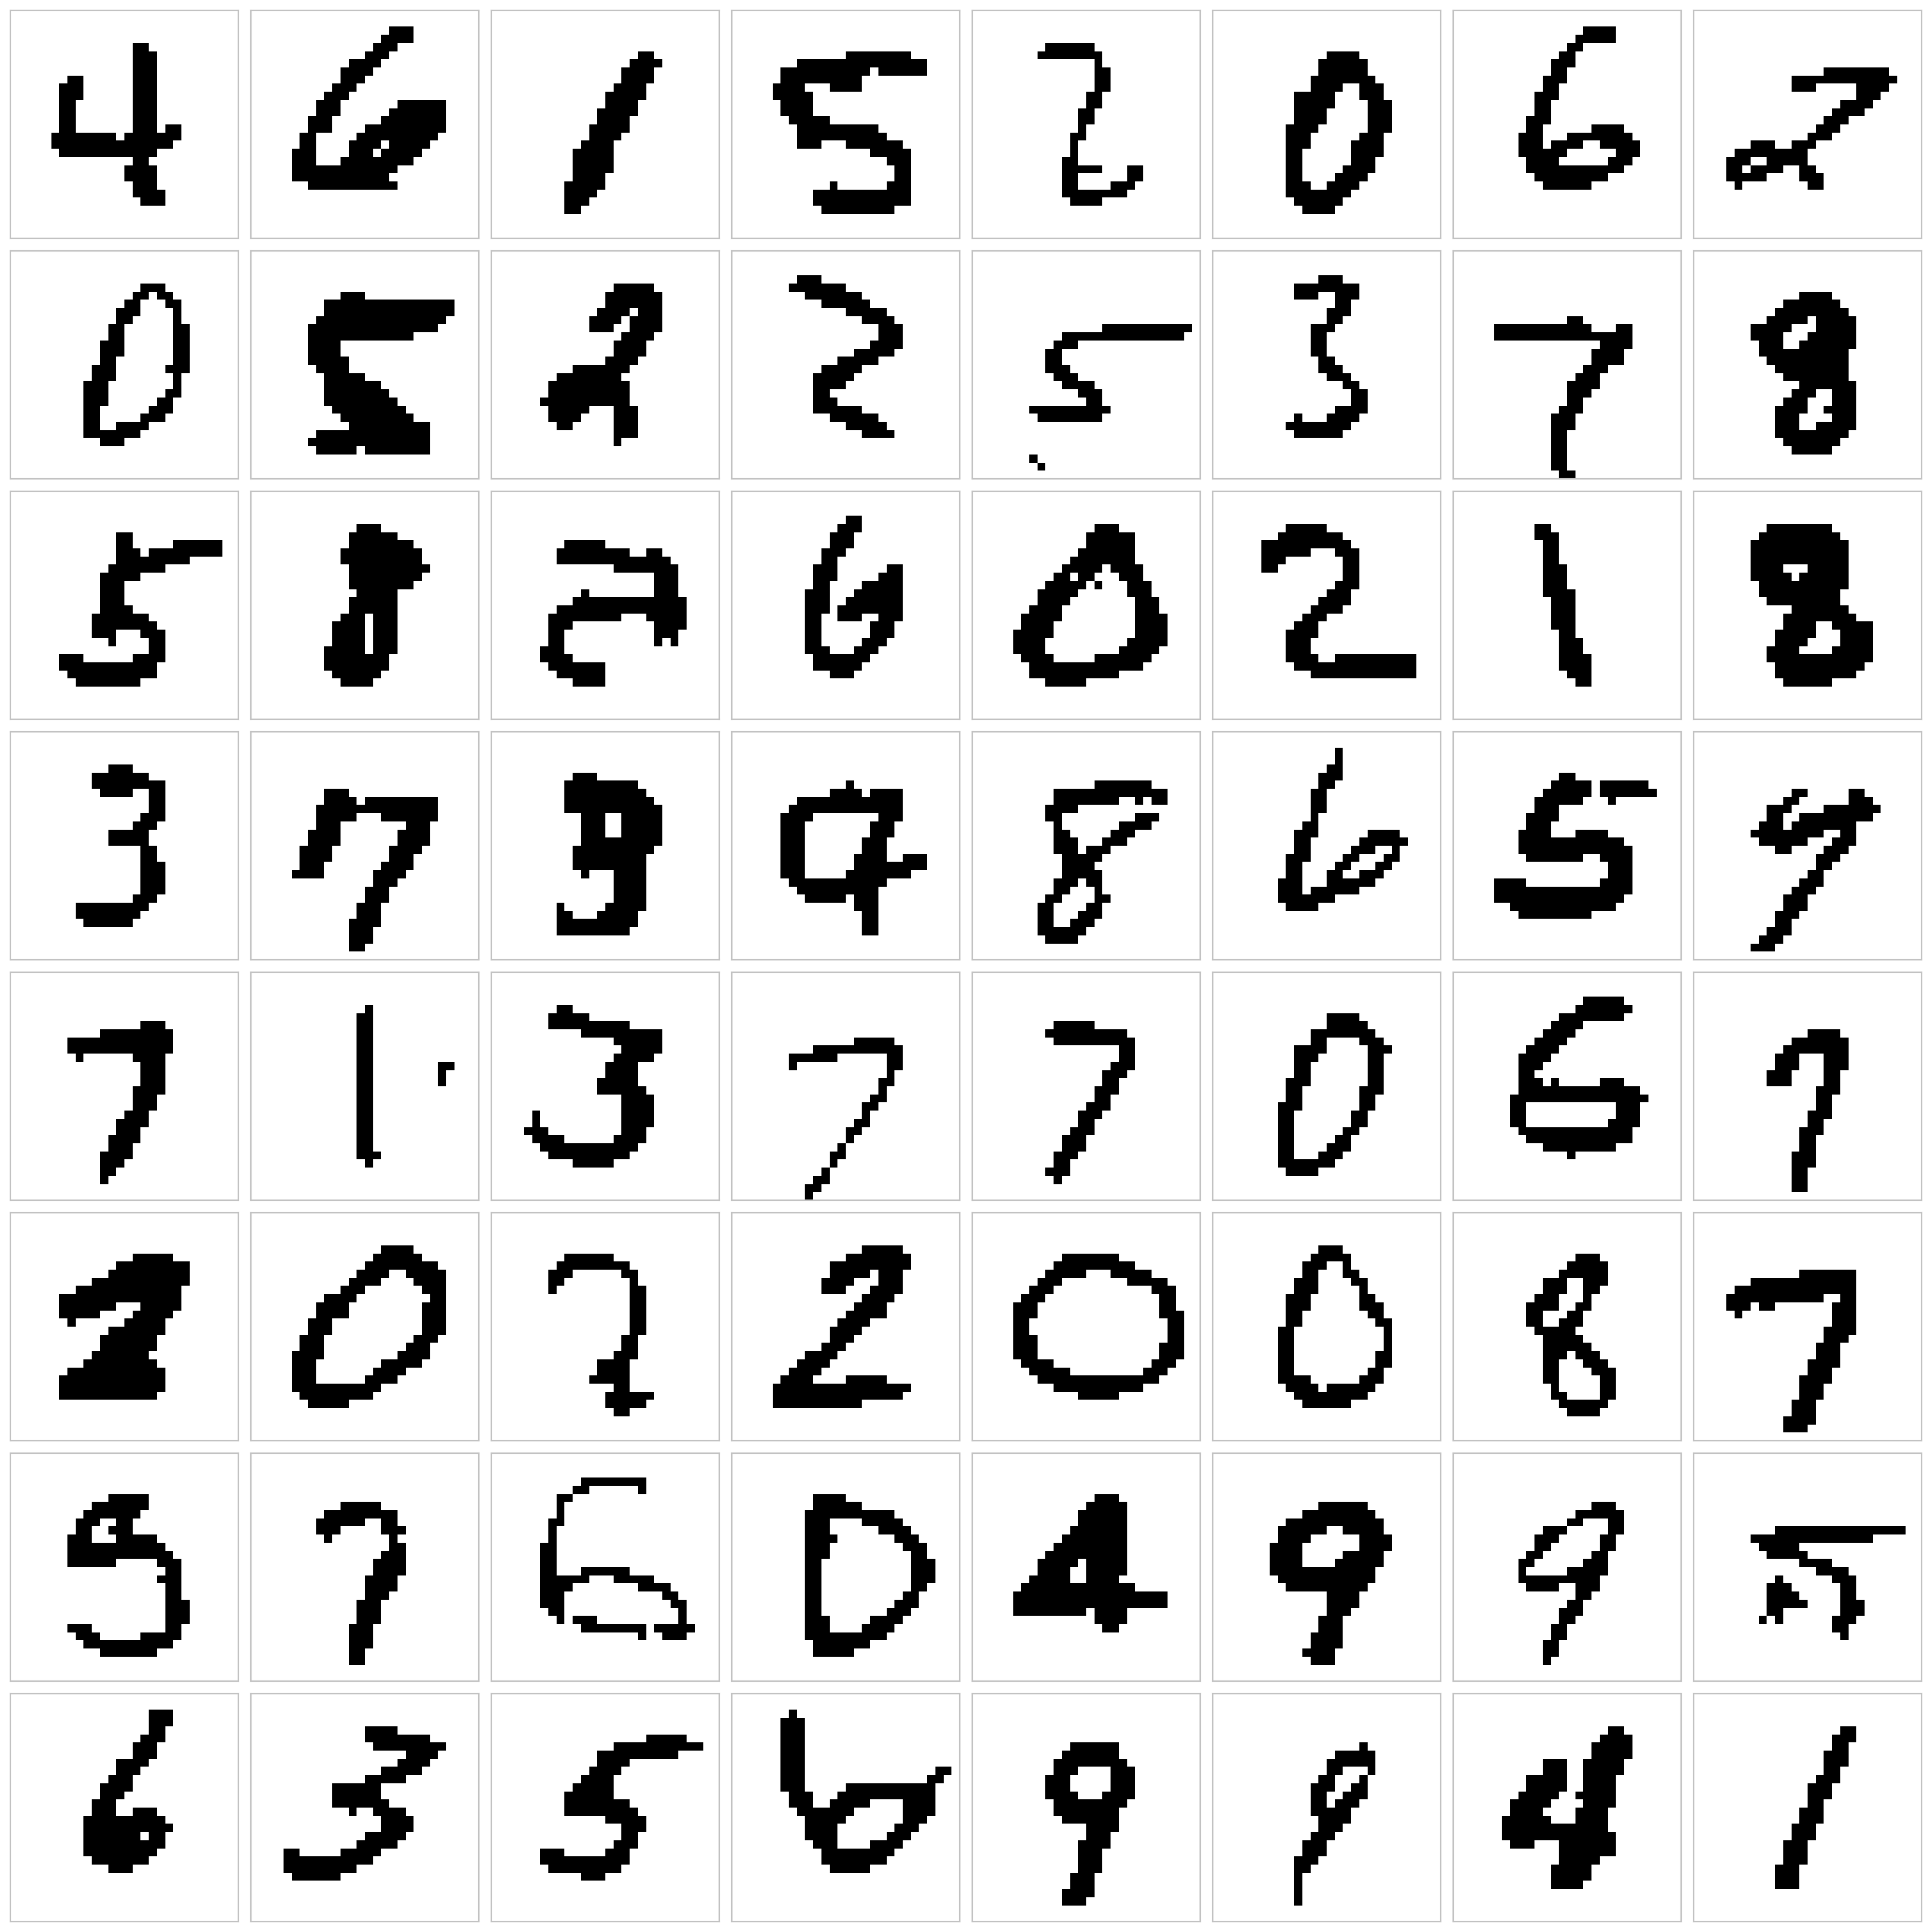

Showing the recorded full batch. Set RUN_SAMPLING=True to generate a new batch.


In [5]:
RUN_SAMPLING = False
if RUN_SAMPLING:
    cli("sample", "--checkpoint", "checkpoints/f02.pt", "--experiment", "f02",
        "--output", "reproduced/f02-samples", "--n", "64", "--seed", "20260921",
        "--capture", "--device", DEVICE)
    display(Image(filename=str(PROJECT_ROOT / "reproduced" / "f02-samples" / "samples.png")))
else:
    display(Image(filename=str(PROJECT_ROOT / "docs" / "figures" / "samples-final.png")))
    print("Showing the recorded full batch. Set RUN_SAMPLING=True to generate a new batch.")

## 5. Train all seven configurations

Enable this cell for fresh full training. The original sum of per-run training/validation times was about 7.77 hours on a TITAN RTX; that does not estimate CPU time or another GPU's speed. The CLI trains S0, S1, S2, S3, G, F0 and F0.2, freezes validation-based choices, and then evaluates the appropriate test checkpoints.

Use a new output directory for a new independent run. Reusing a completed or interrupted directory resumes its full saved states, with configuration checks. The best G checkpoint from the new run initializes both continuations; its selected epoch may differ from the historical epoch 9.

In [6]:
RUN_TRAINING = False
TRAIN_OUTPUT = "runs"
if RUN_TRAINING:
    cli("train", "--experiment", "all", "--output", TRAIN_OUTPUT,
        "--data-root", "data", "--device", DEVICE)
else:
    print("Full training is disabled. Set RUN_TRAINING=True to run all seven experiments.")

Full training is disabled. Set RUN_TRAINING=True to run all seven experiments.


## 6. Sample and plot a new training run

After completing the training cell, enable this cell to produce all seven complete batches and regenerate their curves. No images are selected by visual quality.

In [7]:
REGENERATE_RUN_SAMPLES = False
if REGENERATE_RUN_SAMPLES:
    for experiment in ("s0", "s1", "s2", "s3", "g", "f0", "f02"):
        cli("sample", "--checkpoint", f"{TRAIN_OUTPUT}/{experiment}/pixelcnn_best.pt",
            "--experiment", experiment, "--output", f"{TRAIN_OUTPUT}/{experiment}",
            "--n", "64", "--seed", "20260921", "--capture", "--device", DEVICE)
    run_command(["scripts/plot_results.py", "--input", TRAIN_OUTPUT,
                 "--output", "reproduced/trained-figures"])
else:
    print("New-run sampling is disabled. Enable it after full training has finished.")

New-run sampling is disabled. Enable it after full training has finished.


## 7. Run a single protocol

The experiment IDs are `s0`, `s1`, `s2`, `s3`, `g`, `f0`, and `f02`. The last ID denotes F0.2. A single continuation can start directly from the released historical G checkpoint. This produces a new continuation run and keeps the reference files unchanged.

In [8]:
RUN_SINGLE_EXPERIMENT = False
EXPERIMENT = "f02"
if RUN_SINGLE_EXPERIMENT:
    arguments = ["train", "--experiment", EXPERIMENT, "--output", "runs-single",
                 "--data-root", "data", "--device", DEVICE]
    if EXPERIMENT in ("f0", "f02"):
        arguments += ["--initial-checkpoint", "checkpoints/g.pt"]
    cli(*arguments)
else:
    print("Single-protocol training is disabled. Choose EXPERIMENT and enable it when needed.")

Single-protocol training is disabled. Choose EXPERIMENT and enable it when needed.


## Interpretation

For binary Bernoulli pixels, NLL is the sum of BCE across the image: `NLL/image = 784 × mean BCE/pixel`, and `bits/pixel = mean BCE / ln(2)`. Lower likelihood loss does not directly measure the fraction of recognizable digits.

The recorded F0.2 test NLL is 54.6024, compared with 55.3111 for G and 62.1889 for S0. Full sample batches show both learned digit shapes and failed strokes. The experiments use one training seed, so they compare these complete training schemes rather than prove a separate or cross-seed effect for every component.

See the README for the exact historical dependencies and the anonymous report for the proof, implementation, tables, and complete analysis.